In [1]:
import sys, os
path = os.path.abspath('../src')
sys.path.insert(0, path)

In [2]:
from shapely.geometry import box
import geopandas as gpd

In [3]:
geo = box(-10, 35, 10, 45)
gdf = gpd.GeoDataFrame({'id':[1], 'geometry':[geo]}, crs='EPSG:4326')

geo2 = box(-15, 33, 8, 42)
gdf2 = gpd.GeoDataFrame({'id':[2], 'geometry':[geo2]}, crs='EPSG:4326')


<Axes: >

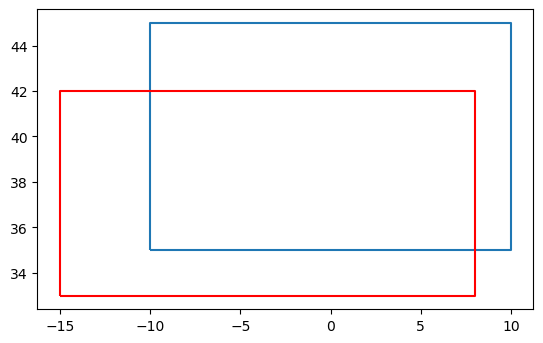

In [4]:
ax = gdf.boundary.plot()
gdf2.boundary.plot(ax=ax, color='red')

<Axes: >

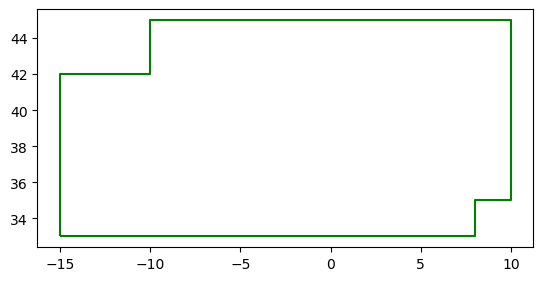

In [5]:
udf = gpd.overlay(gdf, gdf2, how='union').union_all()
udf = gpd.GeoDataFrame(geometry=[udf])
udf.boundary.plot(color='green')

In [6]:
udf.geometry.iloc[0].geom_type

'Polygon'

<Axes: >

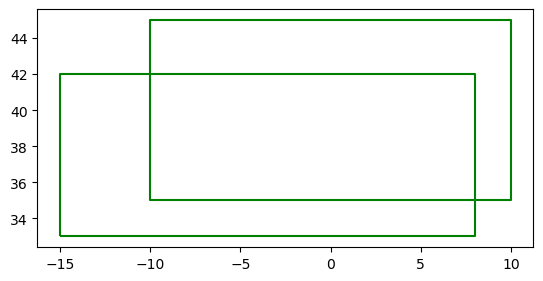

In [9]:
adf = gpd.overlay(gdf, gdf2, how='symmetric_difference').union_all()
adf = gpd.GeoDataFrame(geometry=[adf])
adf.boundary.plot(color='green')
# adf.geometry.iloc[0].is_empty

In [17]:
adf = adf.explode(index_parts=False)

In [18]:
adf

,geometry
0,"POLYGON ((-15 33, -15 42, -10 42, -10 35, 8 35..."
0,"POLYGON ((10 45, 10 35, 8 35, 8 42, -10 42, -1..."


In [20]:
len(adf)

2

In [33]:
[list(zip(*polygon.exterior.coords.xy)) for polygon in adf.geometry]

[[(-15.0, 33.0),
  (-15.0, 42.0),
  (-10.0, 42.0),
  (-10.0, 35.0),
  (8.0, 35.0),
  (8.0, 33.0),
  (-15.0, 33.0)],
 [(10.0, 45.0),
  (10.0, 35.0),
  (8.0, 35.0),
  (8.0, 42.0),
  (-10.0, 42.0),
  (-10.0, 45.0),
  (10.0, 45.0)]]